In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# Load the dataset
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/data.csv")  # Modify according to the path where the file is stored

print(df.head())  # Check that the data loaded correctly

Mounted at /content/drive
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_wor

Perform a brief exploratory analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

 Most columns are of type float and contain no missing values

In [4]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


We observe that the scales can vary between variables

In [5]:
df = df.drop(columns=['Unnamed: 32'])  # Remove the empty column

In [6]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [7]:
# Encode the variables B and M as 0 and 1
df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1})

We observe that there are more benign diagnoses than malignant; approximately 60% of the sample is benign

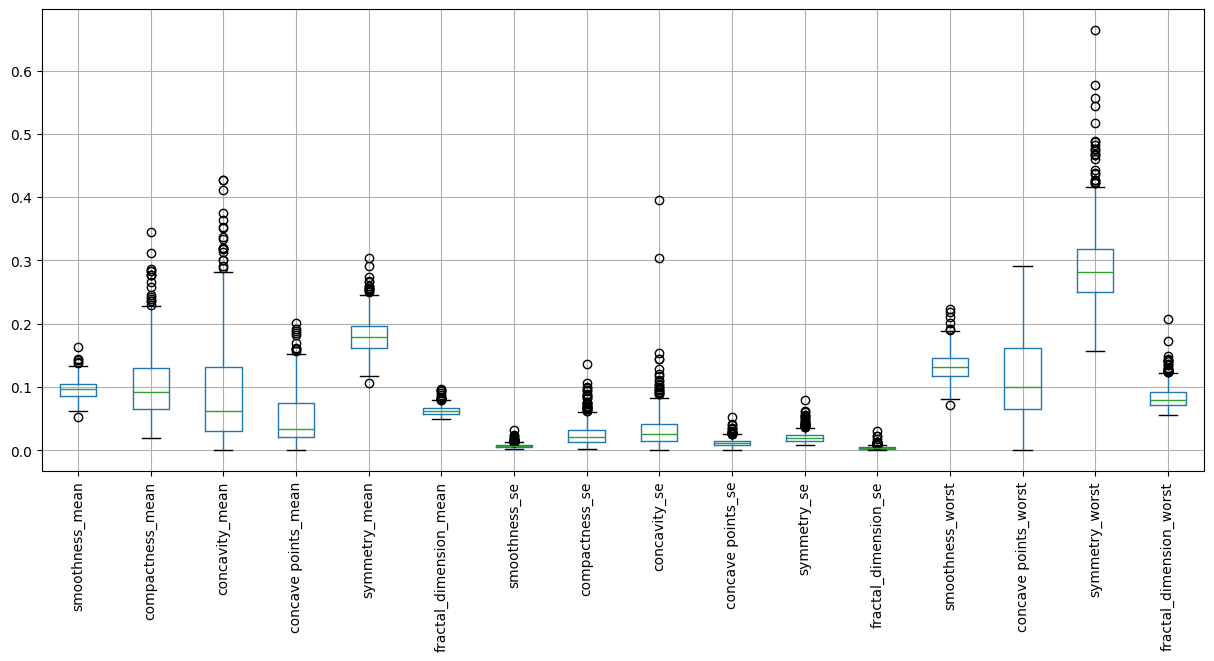

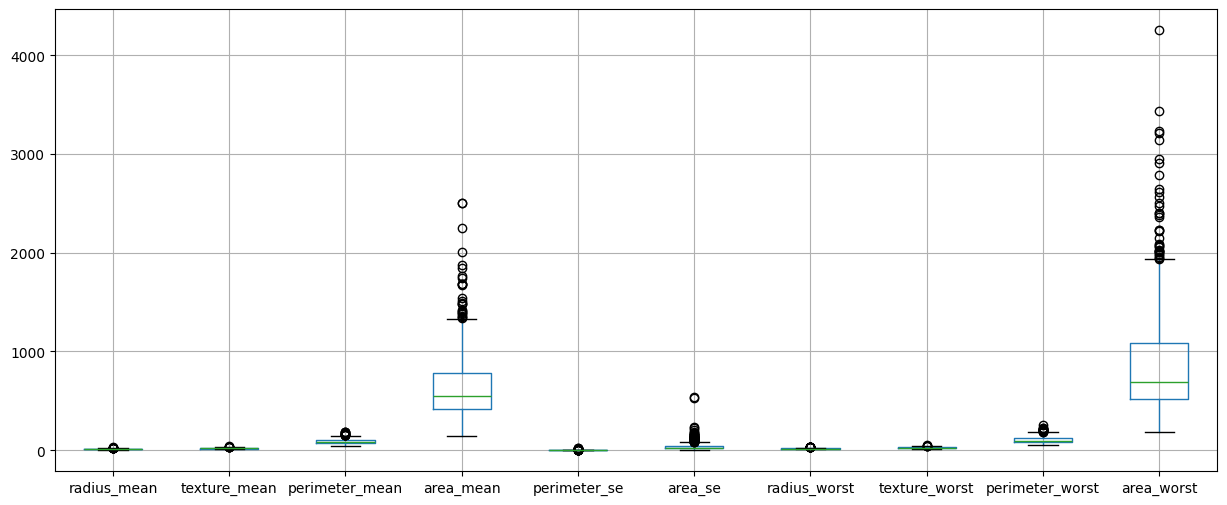

In [8]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('id')
small_scale = [col for col in numeric_cols if df[col].max() < 1]
large_scale = [col for col in numeric_cols if df[col].max() >= 5]

df[small_scale].boxplot(rot=90,figsize=(15,6))
plt.show()

df[large_scale].boxplot(figsize=(15,6))
plt.show()

We observe that almost all variables have outliers, especially on the upper end. Additionally, some variables show considerable variability, while others are more concentrated around their central values. This indicates that the dataset contains a wide range of values and some extreme cases that could potentially influence the analysis.

<Axes: >

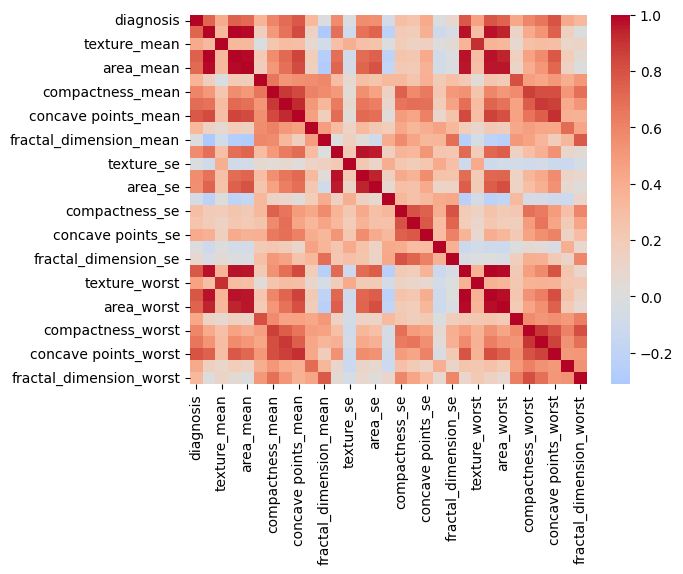

In [9]:
corr_matrix = df.drop(columns=['id']).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)

We observe strong correlations between some variables.

In [10]:
# Features and target
X = df[numeric_cols]  # all numerical columns
y = df['diagnosis']   # target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33, stratify=y)

In [11]:
# Start with the Decision Tree
grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']}

DC = DecisionTreeClassifier()
gridDC = GridSearchCV(DC, grid, cv=5)
gridDC.fit(X_train, y_train)
results = pd.DataFrame(gridDC.cv_results_)

gridDC_10 = GridSearchCV(DC, grid, cv=10)
gridDC_10.fit(X_train, y_train)
results_10 = pd.DataFrame(gridDC_10.cv_results_)

In [12]:
# Create a function to display the best model and its accuracy
def best_model(grid_cv, X_test, y_test):
    print("Best parameters:", grid_cv.best_params_)
    print("Mean CV accuracy:", grid_cv.best_score_)

    accuracy_test = grid_cv.score(X_test, y_test)
    print("Test set accuracy:", accuracy_test)
    print("-" * 40)

    return grid_cv.best_params_, grid_cv.best_score_, accuracy_test


params, cv_score, test_score = best_model(gridDC, X_test, y_test)
params, cv_score, test_score = best_model(gridDC_10, X_test, y_test)

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Mean CV accuracy: 1.0
Test set accuracy: 1.0
----------------------------------------
Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Mean CV accuracy: 1.0
Test set accuracy: 1.0
----------------------------------------


In [13]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Logistic Regression with hyperparameter tuning
grid_RL = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']}

RL = LogisticRegression(max_iter=5000)
gridRL = GridSearchCV(RL, grid_RL, cv=5)
gridRL.fit(X_train_scaled, y_train)
results_RL = pd.DataFrame(gridRL.cv_results_)

gridRL10 = GridSearchCV(RL, grid_RL, cv=10)
gridRL10.fit(X_train_scaled, y_train)
results_RL10 = pd.DataFrame(gridRL10.cv_results_)

In [15]:
params, cv_score, test_score = best_model(gridRL, X_test_scaled, y_test)
params, cv_score, test_score = best_model(gridRL10, X_test_scaled, y_test)


Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Mean CV accuracy: 1.0
Test set accuracy: 1.0
----------------------------------------
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Mean CV accuracy: 1.0
Test set accuracy: 1.0
----------------------------------------


In [16]:
# K-NN with hyperparameter tuning
grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

knn = KNeighborsClassifier()
gridknn = GridSearchCV(knn, grid_knn, cv=5)
gridknn.fit(X_train_scaled, y_train)
results_knn_cv5 = pd.DataFrame(gridknn.cv_results_)

grid_knn10 = GridSearchCV(knn, grid_knn, cv=10)
grid_knn10.fit(X_train_scaled, y_train)
results_knn_cv10 = pd.DataFrame(grid_knn10.cv_results_)

In [17]:
params, cv_score, test_score = best_model(gridknn, X_test_scaled, y_test)
params, cv_score, test_score = best_model(grid_knn10, X_test_scaled, y_test)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Mean CV accuracy: 0.9978021978021978
Test set accuracy: 0.9824561403508771
----------------------------------------
Best parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Mean CV accuracy: 1.0
Test set accuracy: 0.9736842105263158
----------------------------------------


All models achieve very high accuracy, indicating that the data has a clearly separable structure between classes. Additionally, the differences between k=5 and k=10 are minimal, indicating that the models are not sensitive to the data split and therefore have good generalization capability.
